In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import load_model

In [2]:
df = pd.read_csv("PJME_preprocessed.csv")

df.head()

,Datetime,PJME_MW,Hour,Day,DayOfWeek,Month,Year,Week,IsWeekend,Season,...,Month_sin,Month_cos,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24,RollingStd_168
0,2002-01-08 01:00:00,29445.0,1,8,1,1,2002,2,0,Winter,...,0.5,0.866025,31187.0,26862.0,27100.0,30393.0,33560.208333,32513.869048,4425.965952,3861.770954
1,2002-01-08 02:00:00,28670.0,2,8,1,1,2002,2,0,Winter,...,0.5,0.866025,29445.0,25976.0,26097.0,29265.0,33672.458333,32510.327381,4256.159403,3865.039821
2,2002-01-08 03:00:00,28375.0,3,8,1,1,2002,2,0,Winter,...,0.5,0.866025,28670.0,25641.0,25793.0,28357.0,33786.375000,32510.434524,4064.104959,3864.924245
3,2002-01-08 04:00:00,28542.0,4,8,1,1,2002,2,0,Winter,...,0.5,0.866025,28375.0,25666.0,25657.0,27899.0,33906.208333,32514.261905,3851.076461,3860.646270
4,2002-01-08 05:00:00,29261.0,5,8,1,1,2002,2,0,Winter,...,0.5,0.866025,28542.0,26328.0,25778.0,28057.0,34028.416667,32521.428571,3640.941409,3853.433314


In [3]:
features = [
    "PJME_MW",
    
    "Hour_sin",
    "Hour_cos",
    
    "DayOfWeek_sin",
    "DayOfWeek_cos",
    
    "Month",
    "IsWeekend",
    
    "Lag_1",
    "Lag_24",
    "Lag_48",
    "Lag_168",
    
    "RollingMean_24",
    "RollingMean_168",
    "RollingStd_24",
    "RollingStd_168"
]

target = "PJME_MW"

print("Features:")
print(features)

Features:
['PJME_MW', 'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month', 'IsWeekend', 'Lag_1', 'Lag_24', 'Lag_48', 'Lag_168', 'RollingMean_24', 'RollingMean_168', 'RollingStd_24', 'RollingStd_168']


In [4]:
df = df.dropna()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (145224, 24)


In [5]:
test_size = int(len(df) * 0.20)

test_start = len(df) - test_size

remaining = df.iloc[:test_start]

test = df.iloc[test_start:]

In [6]:
validation_hours = 30 * 24

validation_start = len(remaining) - validation_hours

train = remaining.iloc[:validation_start]

validation = remaining.iloc[validation_start:]

In [7]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (115460, 24)
Validation: (720, 24)
Test: (29044, 24)


In [8]:
feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train[features]
)

validation_scaled = feature_scaler.transform(
    validation[features]
)

test_scaled = feature_scaler.transform(
    test[features]
)

In [9]:
target_scaler = MinMaxScaler()

target_train_scaled = target_scaler.fit_transform(
    train[[target]]
)

target_validation_scaled = target_scaler.transform(
    validation[[target]]
)

target_test_scaled = target_scaler.transform(
    test[[target]]
)

In [10]:
import joblib

joblib.dump(
    feature_scaler,
    "feature_scaler.pkl"
)

joblib.dump(
    target_scaler,
    "target_scaler.pkl"
)

print("Scalers saved successfully!")

Scalers saved successfully!


In [11]:
def create_sequences(
    X_data,
    y_data,
    input_length=168,
    output_length=24
):

    X = []
    y = []

    for i in range(
        len(X_data) - input_length - output_length + 1
    ):

        X.append(
            X_data[
                i:i + input_length
            ]
        )

        y.append(
            y_data[
                i + input_length:
                i + input_length + output_length
            ]
        )

    return np.array(X), np.array(y)

In [12]:
val_X_input = np.concatenate([
    train_scaled[-168:],
    validation_scaled
])

val_y_input = np.concatenate([
    target_train_scaled[-168:],
    target_validation_scaled
])

In [13]:
X_val, y_val = create_sequences(
    val_X_input,
    val_y_input,
    input_length=168,
    output_length=24
)

In [14]:
y_val = y_val.reshape(
    y_val.shape[0],
    24
)

In [15]:
final_model = load_model(
    "best_gru_phase06.keras"
)

In [16]:
y_val_pred = final_model.predict(
    X_val,
    verbose=1
)

print("Prediction shape:", y_val_pred.shape)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Prediction shape: (697, 24)


In [17]:
print("Prediction sample:")
print(y_val_pred[0])

print("\nActual scaled sample:")
print(y_val[0])

Prediction sample:
[0.36901712 0.35501996 0.3274879  0.29057202 0.2562934  0.22915031
 0.21362425 0.21394423 0.23005216 0.26306564 0.3060821  0.3492939
 0.37422824 0.3868457  0.38294291 0.37336874 0.35949874 0.34554547
 0.33685452 0.3338983  0.33407348 0.3435472  0.36828744 0.38481173]

Actual scaled sample:
[0.38082798 0.35464026 0.31239861 0.26773412 0.23707995 0.22212156
 0.21698093 0.22203729 0.23821763 0.28711682 0.37025176 0.41432635
 0.40292847 0.38440956 0.37132624 0.35963341 0.34543348 0.33713262
 0.32493416 0.31989887 0.32200569 0.33294006 0.35017381 0.39620773]


In [18]:
def inverse_target(data):

    original_shape = data.shape

    data = data.reshape(-1, 1)

    data = target_scaler.inverse_transform(
        data
    )

    return data.reshape(original_shape)

In [19]:
y_val_actual = inverse_target(y_val)

y_val_forecast = inverse_target(y_val_pred)

In [20]:
print("Actual:")
print(y_val_actual[0])

print("\nForecast:")
print(y_val_forecast[0])

Actual:
[32620. 31377. 29372. 27252. 25797. 25087. 24843. 25083. 25851. 28172.
 32118. 34210. 33669. 32790. 32169. 31614. 30940. 30546. 29967. 29728.
 29828. 30347. 31165. 33350.]

Forecast:
[32059.398 31395.021 30088.213 28336.    26708.965 25420.62  24683.676
 24698.861 25463.426 27030.41  29072.186 31123.234 32306.744 32905.633
 32720.387 32265.947 31607.607 30945.316 30532.8   30392.482 30400.799
 30850.467 32024.764 32809.086]


In [21]:
actual_30 = y_val_actual.flatten()

forecast_30 = y_val_forecast.flatten()

print(actual_30.shape)
print(forecast_30.shape)

(16728,)
(16728,)


In [22]:
def evaluate_forecast(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    bias = np.mean(
        y_pred - y_true
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "Bias": bias
    }

In [23]:
results_30 = evaluate_forecast(
    actual_30,
    forecast_30
)

results_30

{'MAE': 1407.507849862506,
 'MSE': 3283891.2359218844,
 'RMSE': np.float64(1812.1509969982867),
 'MAPE': np.float64(4.758343723170216),
 'R2': 0.739660050289187,
 'Bias': np.float64(207.69819338272663)}

In [24]:
validation_30_df = pd.DataFrame(
    [results_30]
)

validation_30_df

,MAE,MSE,RMSE,MAPE,R2,Bias
0,1407.50785,3.283891e+06,1812.150997,4.758344,0.73966,207.698193


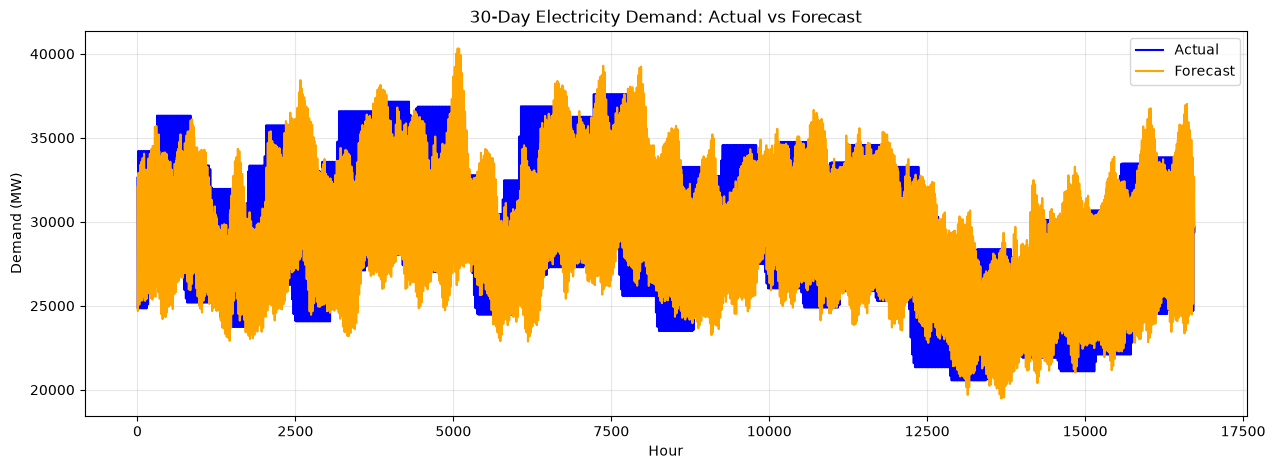

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(
    actual_30,
    label="Actual",
    color="blue"
)

plt.plot(
    forecast_30,
    label="Forecast",
    color="orange"
)

plt.title(
    "30-Day Electricity Demand: Actual vs Forecast"
)

plt.xlabel("Hour")

plt.ylabel("Demand (MW)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [26]:
complete_hours = (
    len(actual_30) // 24
) * 24

daily_mae = np.abs(
    actual_30[:complete_hours]
    - forecast_30[:complete_hours]
).reshape(-1, 24).mean(axis=1)

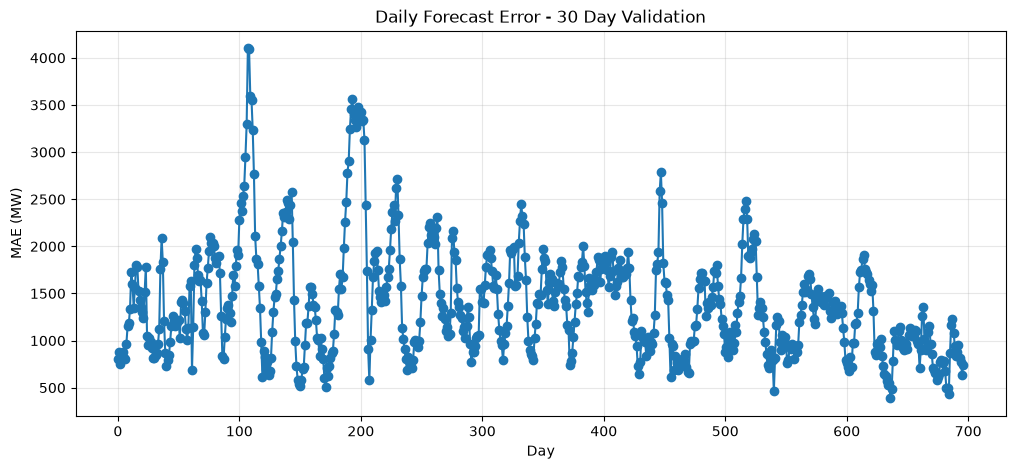

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_mae,
    marker="o"
)

plt.title(
    "Daily Forecast Error - 30 Day Validation"
)

plt.xlabel("Day")

plt.ylabel("MAE (MW)")

plt.grid(alpha=0.3)

plt.show()

In [28]:
#Peak demand error



peak_threshold = np.percentile(
    actual_30,
    90
)

peak_mask = actual_30 >= peak_threshold
peak_mae = mean_absolute_error(
    actual_30[peak_mask],
    forecast_30[peak_mask]
)

print(
    "Peak Demand MAE:",
    peak_mae
)


Peak Demand MAE: 1974.6824358258928


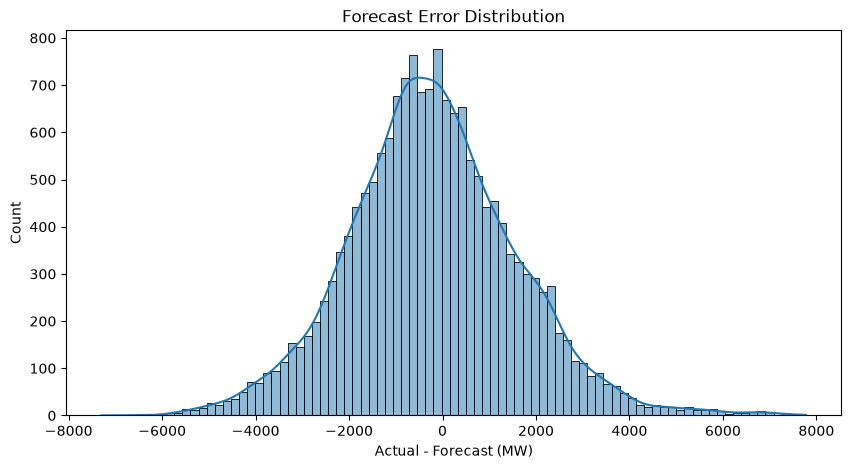

In [29]:
# Error distribution
errors = (
    actual_30 - forecast_30
)

plt.figure(figsize=(10, 5))

sns.histplot(
    errors,
    kde=True
)

plt.title(
    "Forecast Error Distribution"
)

plt.xlabel(
    "Actual - Forecast (MW)"
)

plt.show()

In [30]:
# 60-day validation

validation_hours = 60 * 24

validation_start = len(remaining) - validation_hours

train_60 = remaining.iloc[:validation_start]

validation_60 = remaining.iloc[validation_start:]

print("Train:", train_60.shape)
print("Validation:", validation_60.shape)

Train: (114740, 24)
Validation: (1440, 24)


In [31]:
feature_scaler_60 = MinMaxScaler()

train_60_scaled = feature_scaler_60.fit_transform(
    train_60[features]
)

validation_60_scaled = feature_scaler_60.transform(
    validation_60[features]
)

In [32]:
target_scaler_60 = MinMaxScaler()

target_train_60_scaled = target_scaler_60.fit_transform(
    train_60[["PJME_MW"]]
)

target_validation_60_scaled = target_scaler_60.transform(
    validation_60[["PJME_MW"]]
)

In [33]:
val_60_X_input = np.concatenate([
    train_60_scaled[-168:],
    validation_60_scaled
])

val_60_y_input = np.concatenate([
    target_train_60_scaled[-168:],
    target_validation_60_scaled
])

X_val_60, y_val_60 = create_sequences(
    val_60_X_input,
    val_60_y_input,
    input_length=168,
    output_length=24
)

y_val_60 = y_val_60.reshape(
    y_val_60.shape[0],
    24
)

print("X_val_60:", X_val_60.shape)
print("y_val_60:", y_val_60.shape)

X_val_60: (1417, 168, 15)
y_val_60: (1417, 24)


In [34]:
y_pred_60 = final_model.predict(
    X_val_60,
    verbose=1
)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [35]:
def inverse_target_60(data):

    original_shape = data.shape

    data = data.reshape(-1, 1)

    data = target_scaler_60.inverse_transform(data)

    return data.reshape(original_shape)

In [36]:
actual_60 = inverse_target_60(y_val_60)

forecast_60 = inverse_target_60(y_pred_60)

In [37]:
actual_60_flat = actual_60.flatten()
forecast_60_flat = forecast_60.flatten()

results_60 = evaluate_forecast(
    actual_60_flat,
    forecast_60_flat
)

results_60

{'MAE': 1710.4891960163784,
 'MSE': 5378560.77116526,
 'RMSE': np.float64(2319.172432391619),
 'MAPE': np.float64(5.043753733887617),
 'R2': 0.825165134443423,
 'Bias': np.float64(-403.10099898369504)}

In [38]:
validation_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "R2",
        "Bias"
    ],
    "30-Day": [
        results_30["MAE"],
        results_30["MSE"],
        results_30["RMSE"],
        results_30["MAPE"],
        results_30["R2"],
        results_30["Bias"]
    ],
    "60-Day": [
        results_60["MAE"],
        results_60["MSE"],
        results_60["RMSE"],
        results_60["MAPE"],
        results_60["R2"],
        results_60["Bias"]
    ]
})

validation_comparison

,Metric,30-Day,60-Day
0,MAE,1.407508e+03,1.710489e+03
1,MSE,3.283891e+06,5.378561e+06
2,RMSE,1.812151e+03,2.319172e+03
3,MAPE,4.758344e+00,5.043754e+00
4,R2,7.396601e-01,8.251651e-01
5,Bias,2.076982e+02,-4.031010e+02


In [39]:
validation_comparison.to_csv(
    "phase7_validation_comparison.csv",
    index=False
)